# Рекомендательная система на данных Amazon

Что происходит:

1. Автоматически скачивается небольшой датасет отзывов Amazon (**Digital Music, 5-core**).
2. Базовый EDA (распределение рейтингов, количество пользователей и товаров и т.д.).
3. Разбиение на `train` / `test` с помощью **leave-one-out** по времени.
4. Строятся несколько рекомендательных моделей:
   * Бейзлайн: рекомендации самых популярных товаров.
   * Item-based kNN (item-item рекомендации).
   * Матрица латентных факторов (ALS).
5. Оценка качества по метрикам **HR@10, MRR@10, NDCG@10, coverage**.
6. Выводы.


In [1]:
# Удаляем tsfresh, чтобы не мешал
!pip uninstall -y tsfresh

# Ставим implicit. Позволяем pip подобрать совместимые версии scipy
!pip install implicit --quiet


In [2]:
# Импорт библиотек

import os
import gzip
import json
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import coo_matrix

import implicit

# Настройки вывода
pd.set_option("display.max_columns", 50)
plt.style.use("ggplot")


## Загрузка данных

Используем небольшой датасет **Digital Music 5-core** из раздела *"Small" subsets for experimentation*.

Файл: `Digital_Music_5.json.gz`

Источник: [Amazon Review Data 2018 (amazon_v2)](https://cseweb.ucsd.edu/~jmcauley/datasets/amazon_v2/)


In [3]:
# Путь и имя файла
DATA_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_v2/categoryFilesSmall/Digital_Music_5.json.gz"
DATA_PATH = "Digital_Music_5.json.gz"

if not os.path.exists(DATA_PATH):
    print("Скачиваем данные...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("Готово, файл сохранён как", DATA_PATH)
else:
    print("Файл уже существует:", DATA_PATH)


Файл уже существует: Digital_Music_5.json.gz


In [4]:
# Функция парсинга файла в pandas.DataFrame

def parse_gz_json(path):
    """
    Читает gzip-json файл Amazon (по одной записи в строке)
    и возвращает список словарей.
    """
    data = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            data.append(json.loads(line))
    return data

raw_data = parse_gz_json(DATA_PATH)
df = pd.DataFrame(raw_data)

print("Размерность исходного датафрейма:", df.shape)
df.head()


Размерность исходного датафрейма: (169781, 12)


,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,image
0,5.0,3,True,"06 3, 2013",A2TYZ821XXK2YZ,3426958910,{'Format:': ' Audio CD'},Garrett,"This is awesome to listen to, A must-have for ...",Slayer Rules!,1370217600,NaN
1,5.0,NaN,True,"10 11, 2014",A3OFSREZADFUDY,3426958910,{'Format:': ' Audio CD'},Ad,bien,Five Stars,1412985600,NaN
2,5.0,NaN,True,"02 11, 2014",A2VAMODP8M77NG,3426958910,{'Format:': ' Audio CD'},JTGabq,It was great to hear the old stuff again and I...,SLAYER!!!!!!!!!!!!!!!!!!!!!,1392076800,NaN
3,4.0,3,False,"12 7, 2013",AAKSLZ9IDTEH0,3426958910,{'Format:': ' Audio CD'},john F&#039;n doe,well best of's are a bit poison normally but t...,slayer greatest hits! you mean everything righ...,1386374400,NaN
4,5.0,NaN,True,"06 12, 2016",A3OH43OZJLKI09,5557706259,{'Format:': ' Audio CD'},melinda a goodman,What can I say? This is Casting Crowns!!!This ...,"This is a good, blessing filled",1465689600,NaN


## Базовый EDA

Проведём первичный анализ данных:

* Сколько всего отзывов?
* Сколько уникальных пользователей и товаров?
* Распределение рейтингов.
* Простая статистика по числу отзывов на пользователя и на товар.


In [5]:
# Оставим только нужные для рекомендаций поля
cols = ["reviewerID", "asin", "overall", "unixReviewTime"]
df = df[cols].dropna()

print("После отбора столбцов и удаления NaN:", df.shape)
df.head()


После отбора столбцов и удаления NaN: (169781, 4)


,reviewerID,asin,overall,unixReviewTime
0,A2TYZ821XXK2YZ,3426958910,5.0,1370217600
1,A3OFSREZADFUDY,3426958910,5.0,1412985600
2,A2VAMODP8M77NG,3426958910,5.0,1392076800
3,AAKSLZ9IDTEH0,3426958910,4.0,1386374400
4,A3OH43OZJLKI09,5557706259,5.0,1465689600


In [6]:
# Базовые показатели
n_ratings = len(df)
n_users = df["reviewerID"].nunique()
n_items = df["asin"].nunique()

print(f"Всего отзывов: {n_ratings}")
print(f"Уникальных пользователей: {n_users}")
print(f"Уникальных товаров: {n_items}")


Всего отзывов: 169781
Уникальных пользователей: 16566
Уникальных товаров: 11797


Распределение рейтингов:
overall
1.0      2192
2.0      1812
3.0      6792
4.0     23143
5.0    135842
Name: count, dtype: int64


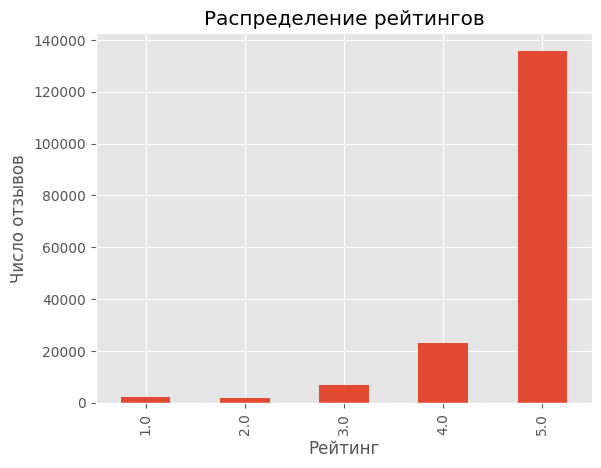

In [7]:
# Распределение рейтингов
rating_counts = df["overall"].value_counts().sort_index()

print("Распределение рейтингов:")
print(rating_counts)

rating_counts.plot(kind="bar")
plt.xlabel("Рейтинг")
plt.ylabel("Число отзывов")
plt.title("Распределение рейтингов")
plt.show()


Основная статистика по числу отзывов на пользователя:
count    16566.000000
mean        10.248763
std         12.376589
min          1.000000
25%          5.000000
50%          7.000000
75%         11.000000
max        791.000000
Name: count, dtype: float64

Основная статистика по числу отзывов на товар:
count    11797.000000
mean        14.391879
std         18.791446
min          1.000000
25%          6.000000
50%          9.000000
75%         15.000000
max        574.000000
Name: count, dtype: float64


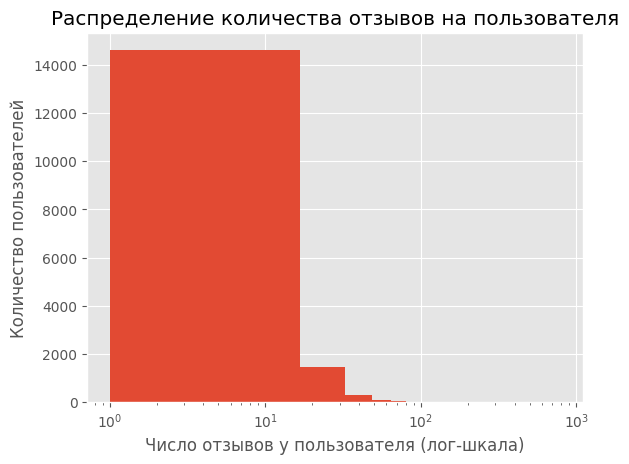

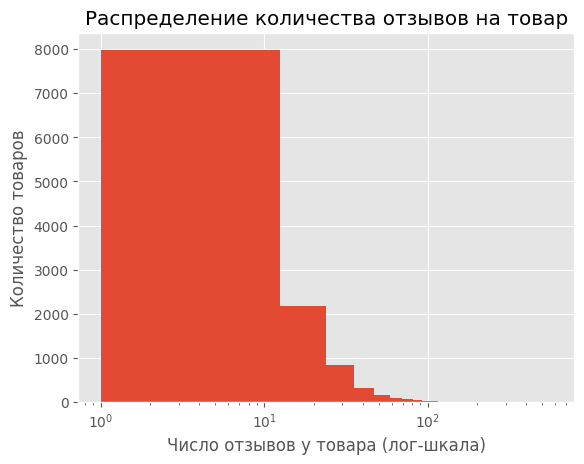

In [8]:
# Количество отзывов на пользователя и на товар

user_counts = df["reviewerID"].value_counts()
item_counts = df["asin"].value_counts()

print("Основная статистика по числу отзывов на пользователя:")
print(user_counts.describe())

print("\nОсновная статистика по числу отзывов на товар:")
print(item_counts.describe())

# Немного визуализации (в лог-шкале, чтобы лучше видеть хвост)
plt.figure()
plt.hist(user_counts.values, bins=50)
plt.xscale("log")
plt.xlabel("Число отзывов у пользователя (лог-шкала)")
plt.ylabel("Количество пользователей")
plt.title("Распределение количества отзывов на пользователя")
plt.show()

plt.figure()
plt.hist(item_counts.values, bins=50)
plt.xscale("log")
plt.xlabel("Число отзывов у товара (лог-шкала)")
plt.ylabel("Количество товаров")
plt.title("Распределение количества отзывов на товар")
plt.show()


## Подготовка данных и разбиение train / test (leave-one-out)

Логика разбиения:

* Для каждого пользователя сортируем его взаимодействия по времени (`unixReviewTime`).
* Самый **последний** отзыв отправляем в `test`.
* Остальные отзывы пользователя остаются в `train`.

Пользователей, у которых всего один отзыв, мы исключим, чтобы в `train` и `test` что-то было.


In [9]:
# Фильтрация пользователей с хотя бы 2 отзывами

user_counts = df["reviewerID"].value_counts()
users_keep = user_counts[user_counts >= 2].index
df = df[df["reviewerID"].isin(users_keep)].copy()

print("После фильтрации пользователей с >=2 отзывами:", df.shape)


После фильтрации пользователей с >=2 отзывами: (169779, 4)


In [10]:
# Сортируем по пользователю и времени
df = df.sort_values(["reviewerID", "unixReviewTime"])

# Нумерация взаимодействий внутри пользователя
df["idx_in_user"] = df.groupby("reviewerID").cumcount()
df["user_size"] = df.groupby("reviewerID")["asin"].transform("size")

# Маска последнего взаимодействия пользователя -> test
test_mask = df["idx_in_user"] == (df["user_size"] - 1)

test_df = df[test_mask].copy()
train_df = df[~test_mask].copy()

print("Размер train:", train_df.shape)
print("Размер test:", test_df.shape)


Размер train: (153215, 6)
Размер test: (16564, 6)


In [11]:
# Строим отображения (user_id -> индекс, item_id -> индекс) по train

unique_users = train_df["reviewerID"].unique()
unique_items = train_df["asin"].unique()

user2idx = {u: i for i, u in enumerate(unique_users)}
item2idx = {i: j for j, i in enumerate(unique_items)}

n_users = len(user2idx)
n_items = len(item2idx)

print("Число пользователей в train:", n_users)
print("Число товаров в train:", n_items)


Число пользователей в train: 16564
Число товаров в train: 11784


In [12]:
# Применяем маппинг индексов

train_df["user_idx"] = train_df["reviewerID"].map(user2idx)
train_df["item_idx"] = train_df["asin"].map(item2idx)

# Оставляем в тесте только тех пользователей и товары, которые есть в train
test_df = test_df[
    test_df["reviewerID"].isin(user2idx) & test_df["asin"].isin(item2idx)
].copy()
test_df["user_idx"] = test_df["reviewerID"].map(user2idx)
test_df["item_idx"] = test_df["asin"].map(item2idx)

print("После синхронизации train/test:")
print("Размер train:", train_df.shape)
print("Размер test:", test_df.shape)


После синхронизации train/test:
Размер train: (153215, 8)
Размер test: (16545, 8)


In [13]:
# Строим разреженную матрицу взаимодействий user-item для train
# Используем неявный отклик (факт взаимодействия, значение = 1.0)

rows = train_df["user_idx"].values
cols = train_df["item_idx"].values
data_values = np.ones(len(train_df), dtype=np.float64)

train_matrix = coo_matrix(
    (data_values, (rows, cols)),
    shape=(n_users, n_items)
).tocsr().astype(np.float64)

print("Размер матрицы train:", train_matrix.shape)


Размер матрицы train: (16564, 11784)


## Метрики качества

Будем оценивать следующие метрики (с @10):

* **HR@10 (Hit Rate)** — доля пользователей, у которых в топ-10 рекомендаций попал настоящий тестовый товар.
* **MRR@10 (Mean Reciprocal Rank)** — среднее значение `1 / rank`, где `rank` — позиция правильного товара в топ-10 (если товара нет в топ-10, вклад 0).
* **NDCG@10** — дисконтированное кумулятивное значение, здесь с одним релевантным объектом упрощается до `1 / log2(rank+1)`.
* **Coverage** — доля товаров из каталога, которые вообще когда-либо были рекомендованы (в топ-10) хотя бы одному пользователю.


In [14]:
def evaluate_model(recommend_func, test_df, train_matrix, k=10):
    """
    recommend_func(user_idx, N) -> список item_idx длины N

    Возвращает словарь с метриками HR@k, MRR@k, NDCG@k, coverage.
    """
    user_indices = test_df["user_idx"].values
    true_items = test_df["item_idx"].values

    hits = []
    mrrs = []
    ndcgs = []
    recommended_items = set()

    for u, true_item in zip(user_indices, true_items):
        recs = list(recommend_func(u, N=k))

        # собираем для coverage
        recommended_items.update(recs)

        if true_item in recs:
            rank = recs.index(true_item)
            hits.append(1.0)
            mrrs.append(1.0 / (rank + 1))
            ndcgs.append(1.0 / np.log2(rank + 2))  # +2, т.к. лог от (rank+1) и индексация с нуля
        else:
            hits.append(0.0)
            mrrs.append(0.0)
            ndcgs.append(0.0)

    hr = float(np.mean(hits))
    mrr = float(np.mean(mrrs))
    ndcg = float(np.mean(ndcgs))
    coverage = len(recommended_items) / train_matrix.shape[1]

    return {
        "HR@10": hr,
        "MRR@10": mrr,
        "NDCG@10": ndcg,
        "coverage": coverage,
    }


## Модель 1: популярные товары (бейзлайн)

Самая простая модель — всегда рекомендовать одни и те же самые популярные товары
(по количеству взаимодействий в train). Для пользователя можно дополнительно исключать уже виденные товары.


In [15]:
# Подсчёт популярности товаров по train
item_popularity = np.asarray(train_matrix.sum(axis=0)).ravel()
popular_items = np.argsort(-item_popularity)  # индексы товаров по убыванию популярности

def recommend_popular(user_idx, N=10):
    """
    Рекомендуем самые популярные товары, исключая те,
    с которыми пользователь уже взаимодействовал.
    """
    user_interactions = set(train_matrix[user_idx].indices)
    recs = []
    for item in popular_items:
        if item not in user_interactions:
            recs.append(int(item))
        if len(recs) >= N:
            break
    return recs

baseline_metrics = evaluate_model(recommend_popular, test_df, train_matrix, k=10)
baseline_metrics


{'HR@10': 0.0119069205197945,
 'MRR@10': 0.005544402711220481,
 'NDCG@10': 0.006991346223951357,
 'coverage': 0.0015274949083503055}

## Модель 2: Item-based kNN (item-item рекомендации)

Используем библиотеку `implicit` и модель `ItemItemRecommender`.
Она строит рекомендации на основе похожести товаров.

Идея: пользователю рекомендуются товары, похожие на те, с которыми он уже взаимодействовал.


In [24]:
# Для библиотеки implicit нужен формат item-user
item_user_matrix = train_matrix.T.tocsr().astype(np.float64)
print("train_matrix shape:", train_matrix.shape)
print("item user matrix shape:",item_user_matrix.shape)

from implicit.nearest_neighbours import ItemItemRecommender

# Параметр K - число соседей у товара
item_knn_model = ItemItemRecommender(K=50)
item_knn_model.fit(item_user_matrix)

def recommend_itemknn(user_idx, N=10):
    """
    Рекомендации из item-based kNN модели.
    filter_already_liked_items=True исключает уже виденные товары.
    """
    user_items = train_matrix[user_idx]
    recs, scores = item_knn_model.recommend(
        user_idx,
        user_items,
        N=N,
        filter_already_liked_items=True
    )
    return [int(i) for i in recs]

itemknn_metrics = evaluate_model(recommend_itemknn, test_df, train_matrix, k=10)
itemknn_metrics


train_matrix shape: (16564, 11784)
item user matrix shape: (11784, 16564)


  0%|          | 0/16564 [00:00<?, ?it/s]

{'HR@10': 0.00042308854638863704,
 'MRR@10': 9.620227661932105e-05,
 'NDCG@10': 0.00017133433896196194,
 'coverage': 0.7040054310930075}

## Модель 3: матричная факторизация (ALS)

Используем `AlternatingLeastSquares` из `implicit`, который приближает матрицу взаимодействий
произведением двух низкоранговых матриц (пользовательские и товарные факторы).

Это классический метод рекомендаций для неявного отклика.


In [35]:
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(
    factors=64,          # размер латентного пространства
    regularization=0.01, # регуляризация
    iterations=15,       # число итераций
    random_state=42,
    use_gpu=False
)

# implicit ожидает item-user матрицу
als_model.fit(train_matrix)

als_model.user_factors.shape


  0%|          | 0/15 [00:00<?, ?it/s]

(16564, 64)

In [36]:
def recommend_als(user_idx, N=10):
    """
    Рекомендации из ALS модели.
    """
    user_items = train_matrix[user_idx]
    recs, scores = als_model.recommend(
        user_idx,
        user_items,
        N=N,
        filter_already_liked_items=True
    )
    return [int(i) for i in recs]

als_metrics = evaluate_model(recommend_als, test_df, train_matrix, k=10)
als_metrics


{'HR@10': 0.027984285282562707,
 'MRR@10': 0.0118386123463186,
 'NDCG@10': 0.015602840976447535,
 'coverage': 0.07255600814663951}

## Сводка метрик для моделей

Соберём результаты по всем моделям в одну таблицу для удобного сравнения.


In [37]:
results = pd.DataFrame(
    [
        ("Популярность (бейзлайн)", baseline_metrics["HR@10"], baseline_metrics["MRR@10"], baseline_metrics["NDCG@10"], baseline_metrics["coverage"]),
        ("Item-based kNN",            itemknn_metrics["HR@10"], itemknn_metrics["MRR@10"], itemknn_metrics["NDCG@10"], itemknn_metrics["coverage"]),
        ("ALS",                       als_metrics["HR@10"], als_metrics["MRR@10"], als_metrics["NDCG@10"], als_metrics["coverage"]),
    ],
    columns=["Модель", "HR@10", "MRR@10", "NDCG@10", "Coverage"]
)

results


,Модель,HR@10,MRR@10,NDCG@10,Coverage
0,Популярность (бейзлайн),0.011907,0.005544,0.006991,0.001527
1,Item-based kNN,0.000423,0.000096,0.000171,0.704005
2,ALS,0.027984,0.011839,0.015603,0.072556


## Выводы

ALS показывает себя лучше остальных моделей. На KNN странные метрики, как будто он дает случайный охват товаров.
